In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.utils import _initialize_pk
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [4]:
# i_snapshots = [-2, -1]
i_snapshots = range(1, 33+4, 4)

In [5]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:41<00:00, 11.26s/it]


In [6]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:40<00:00, 11.13s/it]


# functions

In [7]:
# vmap over the snapshots
vcic_paint_scalar = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,0))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# vmap over features (like velocity components)
vvcic_paint = jax.vmap(vcic_paint, in_axes=(None, None, -1), out_axes=-1)
vvcic_read = jax.vmap(vcic_read, in_axes=(-1, None), out_axes=-1)

def preprocess(snapshot_dict):
    cosmo = snapshot_dict["cosmo"]
    scales = snapshot_dict["scales"]
    
    gas_pos = snapshot_dict["gas_poss"]
    gas_vel = snapshot_dict["gas_vels"]
    
    # rho
    rho_gas = vcic_paint_scalar(jnp.zeros(mesh_shape), gas_pos, cosmo.Omega_b / cosmo.Omega_c)
    gas_rho = vcic_read(rho_gas, gas_pos)
    
    # fscalar
    kvec = fftk(mesh_shape)
    delta_k = jnp.fft.rfftn(rho_gas, axes=(1,2,3))
    fscalar_gas = jnp.fft.irfftn(delta_k * invnabla_kernel(kvec), axes=(1,2,3))
    gas_fscalar = vcic_read(fscalar_gas, gas_pos)
    
    # velocity dispersion
    N_gas = vcic_paint_scalar(jnp.zeros(mesh_shape), gas_pos, 1)
    gas_N = vcic_read(N_gas, gas_pos)
    
    vel_mean_gas = vvcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[...,jnp.newaxis])
    gas_vel_mean = vvcic_read(vel_mean_gas, gas_pos)
    gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)
    vel_disp_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel_disp/gas_N)
    
    # velocity divergence
    vel_gas_k = jnp.fft.rfftn(vel_mean_gas, axes=(1,2,3))
    gas_vel_div = [vcic_read(jnp.fft.irfftn(gradient_kernel(kvec, i) * vel_gas_k[...,i], axes=(1,2,3)), gas_pos) for i in range(len(kvec))]
    gas_vel_div = jnp.stack(gas_vel_div, axis=-1)
    gas_vel_div = jnp.sum(gas_vel_div, axis=-1)
    vel_div_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel_div/gas_N)

    # output
    particle_features = {}
    particle_features["gas_pos"] = gas_pos
    particle_features["gas_rho"] = gas_rho
    particle_features["gas_fscalar"] = gas_fscalar
    particle_features["gas_disp"] = gas_vel_disp
    particle_features["gas_div"] = gas_vel_div
    
    particle_features["gas_P"] = snapshot_dict["gas_Ps"]
    particle_features["gas_U"] = snapshot_dict["gas_Us"]
    particle_features["gas_T"] = snapshot_dict["gas_Ts"]

    field_features = {}
    field_features["rho_gas"] = rho_gas
    field_features["fscalar_gas"] = fscalar_gas
    field_features["vel_disp_gas"] = vel_disp_gas
    field_features["vel_div_gas"] = vel_div_gas

    field_features["P_gas"] = vcic_paint(jnp.zeros(mesh_shape), gas_pos, snapshot_dict["gas_Ps"]/gas_N) 
    field_features["U_gas"] = vcic_paint(jnp.zeros(mesh_shape), gas_pos, snapshot_dict["gas_Us"]/gas_N) 
    field_features["T_gas"] = vcic_paint(jnp.zeros(mesh_shape), gas_pos, snapshot_dict["gas_Ts"]/gas_N) 

    return particle_features, field_features


In [8]:
# # vmap over features (like velocity components)
# vcic_paint = jax.vmap(cic_paint, in_axes=(None, None, -1), out_axes=-1)
# vcic_read = jax.vmap(cic_read, in_axes=(-1, None), out_axes=-1)

# def preprocess(snapshot_dict):
#     cosmo = snapshot_dict["cosmo"]
#     scales = snapshot_dict["scales"]

#     gas_pos = snapshot_dict["gas_poss"]
#     gas_vel = snapshot_dict["gas_vels"]
    
#     # rho
#     rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, cosmo.Omega_b / cosmo.Omega_c)
#     gas_rho = cic_read(rho_gas, gas_pos)
    
#     # fscalar
#     kvec = fftk(mesh_shape)
#     delta_k = jnp.fft.rfftn(rho_gas)
#     fscalar_gas = jnp.fft.irfftn(delta_k * invnabla_kernel(kvec))
#     gas_fscalar = cic_read(fscalar_gas, gas_pos)

#     # velocity dispersion
#     N_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, 1)
#     gas_N = cic_read(N_gas, gas_pos)

#     vel_mean_gas = vcic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel/gas_N[:,jnp.newaxis])
#     gas_vel_mean = vcic_read(vel_mean_gas, gas_pos)
#     gas_vel_disp = jnp.sum((gas_vel_mean - gas_vel)**2, axis=-1)
#     vel_disp_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel_disp/gas_N)

#     # velocity divergence
#     vel_gas_k = jnp.fft.rfftn(vel_mean_gas, axes=(0,1,2))
#     gas_vel_div = [cic_read(jnp.fft.irfftn(gradient_kernel(kvec, i) * vel_gas_k[...,i]), gas_pos) for i in range(len(kvec))]
#     gas_vel_div = jnp.stack(gas_vel_div, axis=-1)
#     gas_vel_div = jnp.sum(gas_vel_div, axis=-1)
#     vel_div_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, gas_vel_div/gas_N)

#     # output
#     particle_features = {}
#     particle_features["gas_pos"] = gas_pos
#     particle_features["gas_rho"] = gas_rho
#     particle_features["gas_fscalar"] = gas_fscalar
#     particle_features["gas_disp"] = gas_vel_disp
#     particle_features["gas_div"] = gas_vel_div
    
#     particle_features["gas_P"] = snapshot_dict["gas_Ps"]
#     particle_features["gas_U"] = snapshot_dict["gas_Us"]
#     particle_features["gas_T"] = snapshot_dict["gas_Ts"]

#     field_features = {}
#     field_features["rho_gas"] = rho_gas
#     field_features["fscalar_gas"] = fscalar_gas
#     field_features["vel_disp_gas"] = vel_disp_gas
#     field_features["vel_div_gas"] = vel_div_gas
    
#     return particle_features, field_features

In [9]:
scales = train_dict["scales"]
particle_features, field_features = preprocess(train_dict)

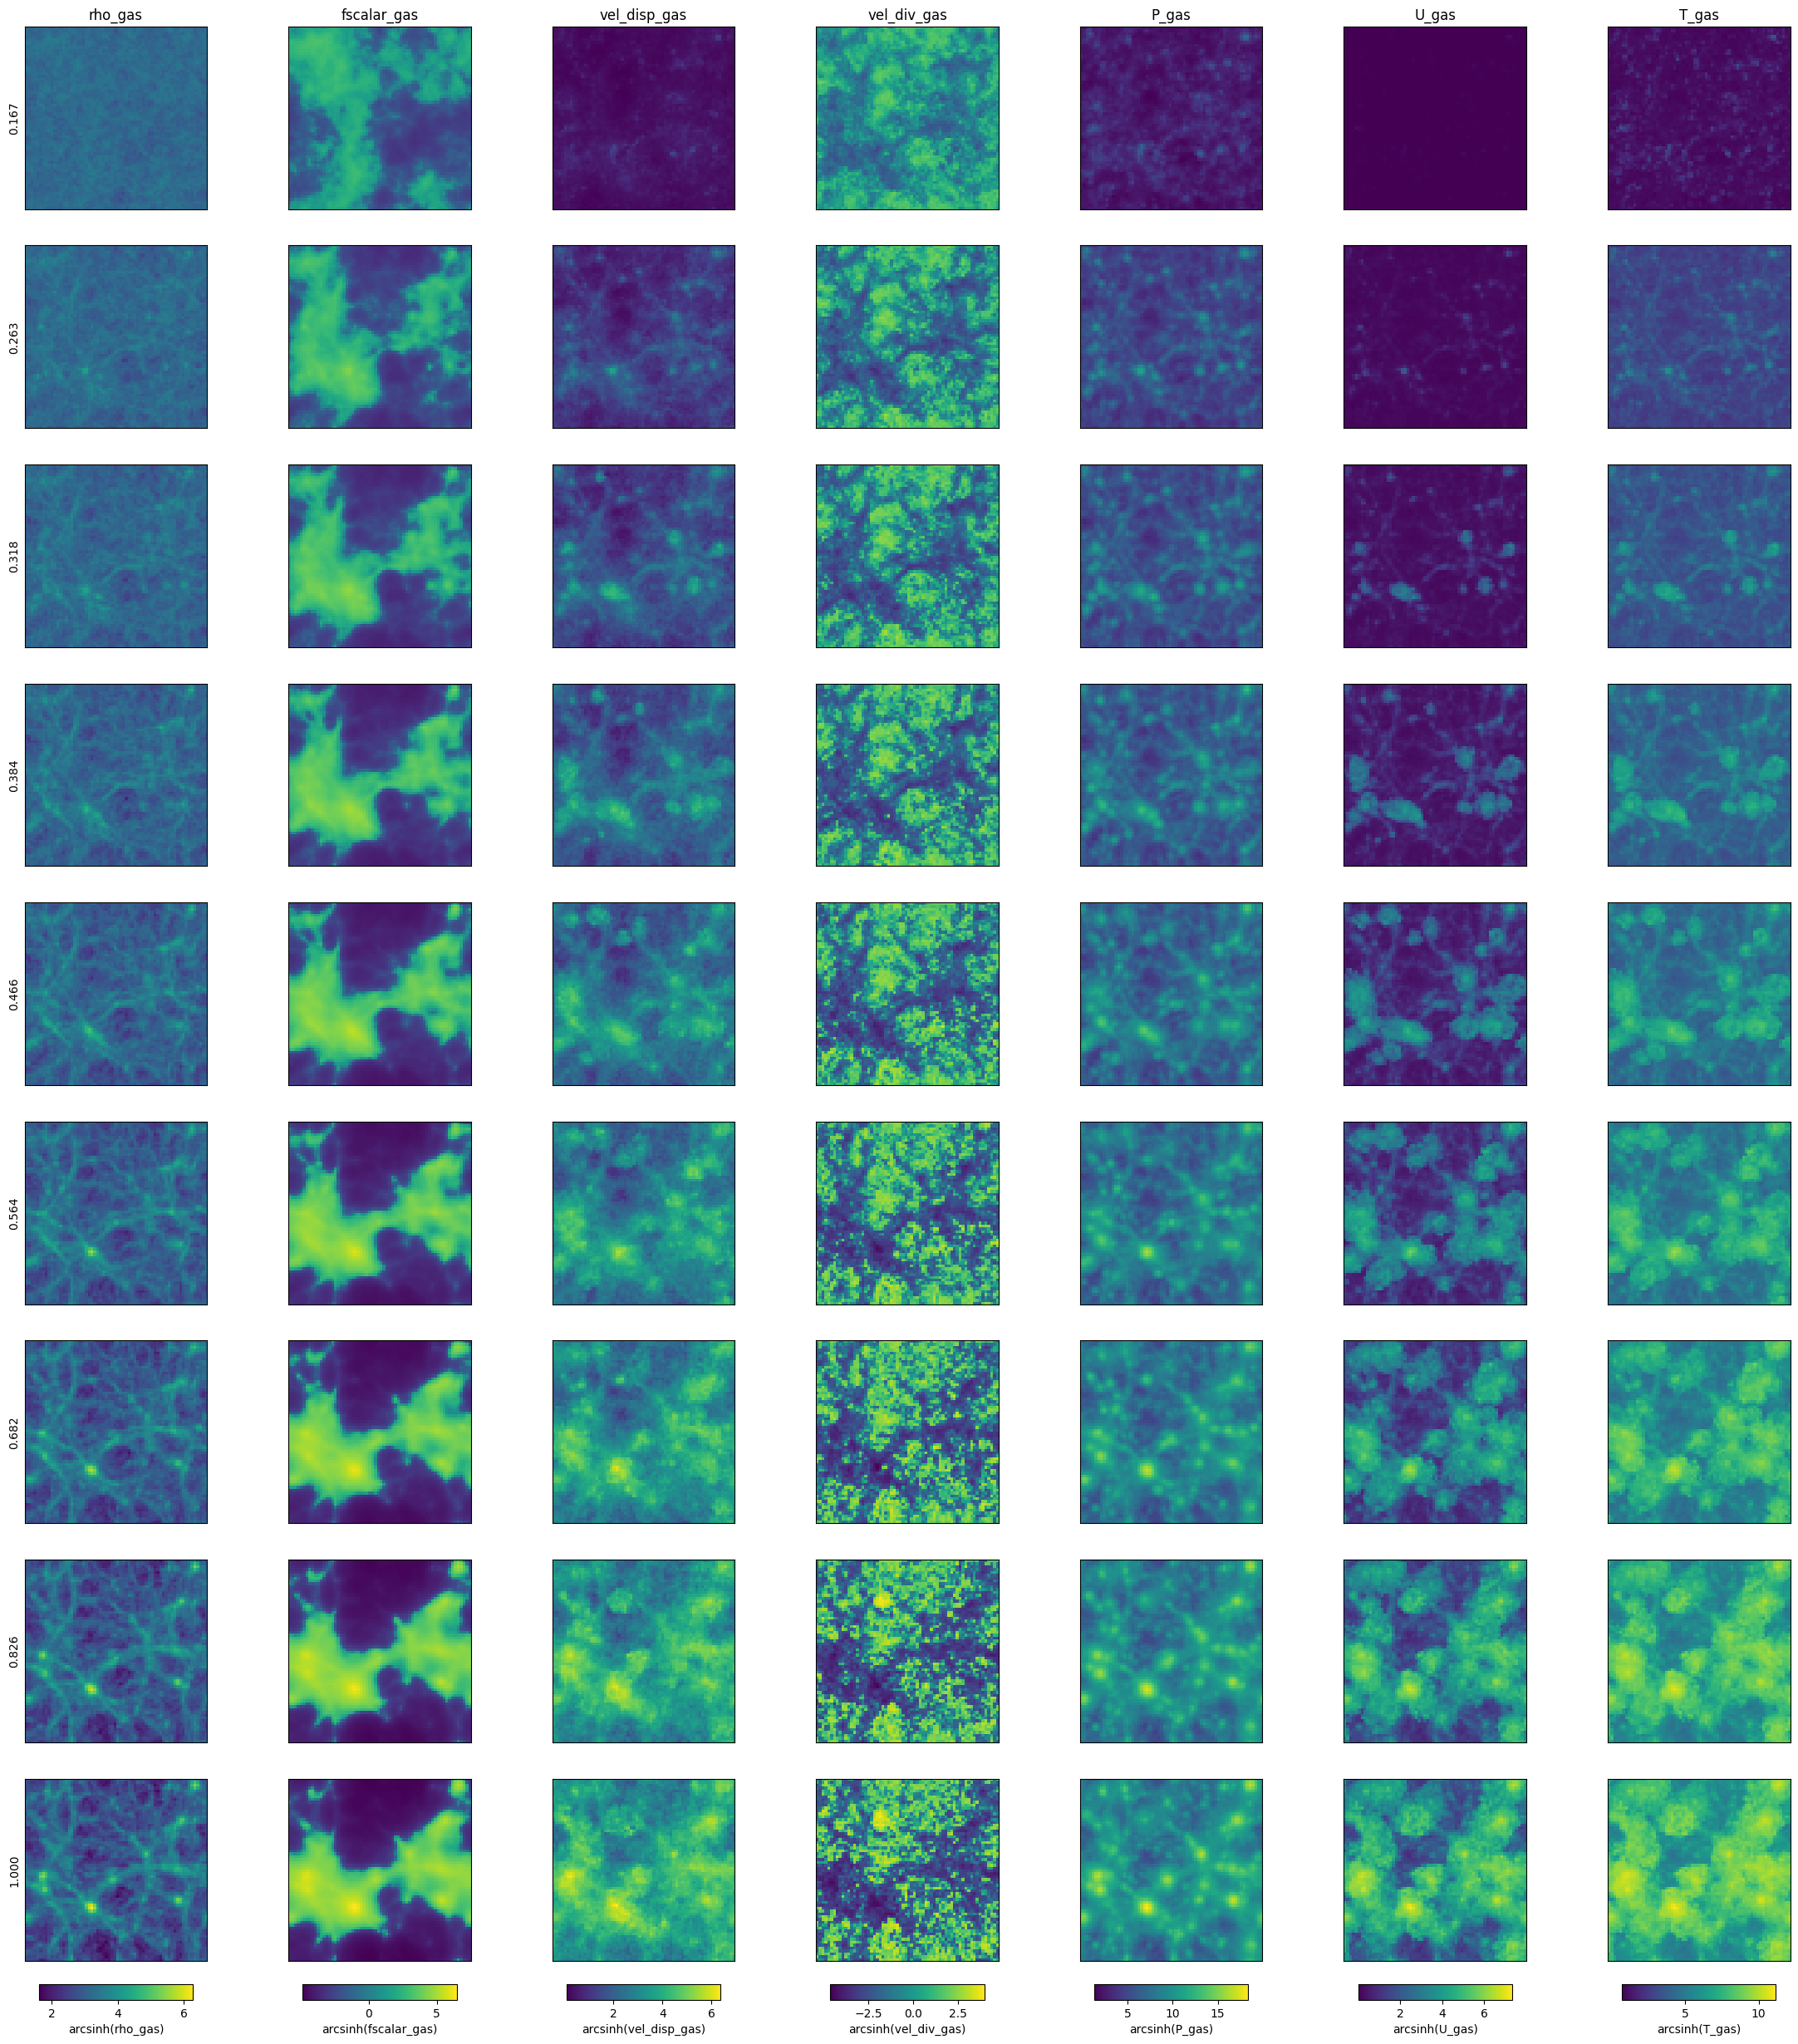

In [10]:
features = ["rho_gas", "fscalar_gas", "vel_disp_gas", "vel_div_gas", "P_gas", "U_gas", "T_gas"]

nrows = len(scales)
ncols = len(features)

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4,nrows*4))

for j in range(ncols):
    fields = field_features[features[j]]
    fields = jnp.arcsinh(jnp.sum(fields, axis=1))
    vmin, vmax = fields.min(), fields.max()

    for i in range(nrows):
        field = fields[i]

        im = ax[i,j].imshow(field, vmin=vmin, vmax=vmax)

        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

        if i == 0:
            ax[i,j].set(title=features[j])
        if i == nrows - 1:
            fig.colorbar(
                im,
                ax=ax[:,j],
                orientation="horizontal",
                shrink=0.7,
                aspect=10,
                pad=0.01,
                label=f"arcsinh({features[j]})",
            )
        if j == 0:
            ax[i,j].set(ylabel=f"{scales[i]:.3f}")

In [11]:
def get_data(
    snapshot_dict, 
    flatten=True,
    x_labels=["rho", "fscalar", "disp", "div"],
    y_labels=["P", "U", "T"],
):
    particle_features, field_features = preprocess(snapshot_dict)

    X_particle = jnp.stack(
        [
            jnp.log10(particle_features["gas_rho"] + 1),
            jnp.arcsinh(particle_features["gas_fscalar"]/100),
            jnp.log10(particle_features["gas_disp"] + 1),
            jnp.arcsinh(particle_features["gas_div"]/100)

        ], 
        axis=-1
    )

    X_field = jnp.stack(
        [
            jnp.log10(field_features["rho_gas"] + 1), 
            jnp.arcsinh(field_features["fscalar_gas"]/100),
        ],
        axis=-1
    )

    Y_particle = []
    for y_label in y_labels:
        Y_particle.append(jnp.log10(particle_features[f"gas_{y_label}"] + 1))
    Y_particle = jnp.stack(Y_particle, axis=-1)
    
    return X_particle, X_field, Y_particle

In [12]:
# def get_data(
#     snapshot_dict, 
#     flatten=True,
#     x_labels=["rho", "fscalar", "disp", "div"],
#     y_labels=["P", "U", "T"],
# ):
#     particle_features, field_features = preprocess(snapshot_dict)

#     X_particle = jnp.stack(
#         [
#             jnp.log10(particle_features["gas_rho"] + 1),
#             jnp.arcsinh(particle_features["gas_fscalar"]/100),
#             jnp.log10(particle_features["gas_disp"] + 1),
#             jnp.arcsinh(particle_features["gas_div"]/100)

#         ], 
#         axis=-1
#     )

#     X_field = jnp.stack(
#         [
#             jnp.log10(field_features["rho_gas"] + 1), 
#             jnp.arcsinh(field_features["fscalar_gas"]/100),
#         ],
#         axis=-1
#     )
    
#     Y_particle = jnp.stack(
#         [
#             jnp.log10(particle_features["gas_P"] + 1),
#             jnp.log10(particle_features["gas_U"] + 1),
#             jnp.log10(particle_features["gas_T"] + 1),
#         ]
#         , 
#         axis=-1
#     )

#     return X_particle, X_field, Y_particle

In [13]:
# def particle_loss_fn(model):
#     y_pred = model(x)
#     return jnp.mean((y - y_pred) **2)

@nnx.jit
def train_step(model, optimizer, x, y):

    def loss_fn(model):
        y_pred = model(*x)
        return jnp.mean((y - y_pred) **2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss
    

In [14]:
# @nnx.jit
def vali_loop(model, X, Y):
    losses = []
    for i in range(scales.shape[0]):
        x, y = tuple(x[i] for x in X), Y[i]
        
        losses.append(jnp.mean((y - model(*x))**2))
    losses = jnp.mean(jnp.stack(losses))

    return losses

In [15]:
# NOTE this is GD, not SGD. There's no batches, all particles in the snapshot are evaluated every step
def train_model(
    model, 
    X,
    Y,
    X_vali,
    Y_vali,
    total_steps=1_000,
    vali_every=100,
    learning_rate=1e-3,
    cosine_decay=False,
):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1),
        optax.adam(learning_rate)
    )
    optimizer = nnx.Optimizer(model, optimizer)

    if cosine_decay:
        learning_rate = optax.cosine_decay_schedule(
            init_value=learning_rate, 
            decay_steps=total_steps, 
            alpha=0.1
        )

    losses = []
    vali_steps = []
    vali_losses = []
    vali_loss = np.inf
    for i in (pbar := tqdm.tqdm(range(total_steps))):
        # select single snapshot
        j = np.random.choice(np.arange(scales.shape[0]))
        x, y = tuple(x[j] for x in X), Y[j]
        
        loss = train_step(model, optimizer, x, y)
        losses.append(loss)

        if (i % vali_every == 0) and (i != 0) or i == total_steps - 1:
            vali_steps.append(i)
            vali_loss = vali_loop(model, X_vali, Y_vali)
            vali_losses.append(vali_loss)

        pbar.set_description(f"train={loss:.4f}, vali={vali_loss:.4f}")

    fig, ax = plt.subplots()
    ax.plot(losses, label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend(loc="upper right")
    ax.set(yscale="log")
    

In [16]:
def plot_preds(pred, label, pred_vali, label_vali):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    # fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))
    # ncols = y_true.shape[-1]

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        # ax[i].set_yticks(ax[i].get_xticks())
    
    ax[0,1].set(title="validation")

    fig.tight_layout()

In [17]:
def normalized_paint(positions, weights):
    N_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_N = cic_read(N_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_N)


def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims
    
    return ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax), vlims, log_sum


def plot_comparison(true_field, pred_field, true_label="CAMELS", pred_label="", quantity_label="P", suptitle=""):
    fig, ax = plt.subplots(figsize=(3*6, 6+1), ncols=3)
    
    im, vlims, true_field_log_sum = plot_field(true_field, ax[0])
    ax[0].set(title=true_label)
    
    im, _, pred_field_log_sum = plot_field(pred_field, ax[1], vlims=vlims)
    ax[1].set(title=pred_label)
    
    fig.colorbar(im, ax=ax[:2], label=f"log(sum({quantity_label}))", orientation="horizontal", shrink=0.6, aspect=20)
    
    residual = true_field_log_sum - pred_field_log_sum
    lim = np.max(np.abs(residual[np.isfinite(residual)]))
    print(lim)
    im = ax[2].imshow(residual, cmap="seismic", vmin=-lim, vmax=lim)
    ax[2].set(title="residual (true - pred)")
    fig.colorbar(im, ax=ax[2], label=f"log(sum({quantity_label}_1)) - log(sum({quantity_label}_2))", orientation="horizontal", shrink=0.6, aspect=10)
    
    for i in range(len(ax)):
        ax[i].set_yticks([])
        ax[i].set_xticks([])
    
    fig.suptitle(suptitle, fontsize=16)

# particle-level

## MLP

In [18]:
from jaxpm.nn import MLP

train=0.1021, vali=0.1742: 100%|██████████| 1000/1000 [00:12<00:00, 82.41it/s]


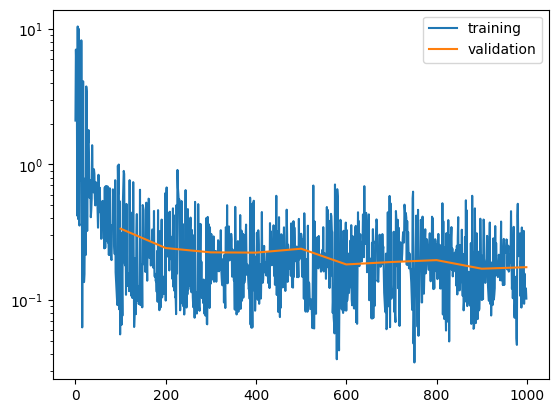

In [19]:
y_labels = ["P"]
# y_labels = ["U"]

X, _, Y = get_data(train_dict, y_labels=y_labels)
X_vali, _, Y_vali = get_data(test_dict, y_labels=y_labels)

model = MLP(
    X.shape[-1], 
    Y.shape[-1], 
    64, 
    4, 
    nnx.Rngs(0)
)

train_model(
    model,
    (X,),
    Y,
    (X_vali,),
    Y_vali,
)

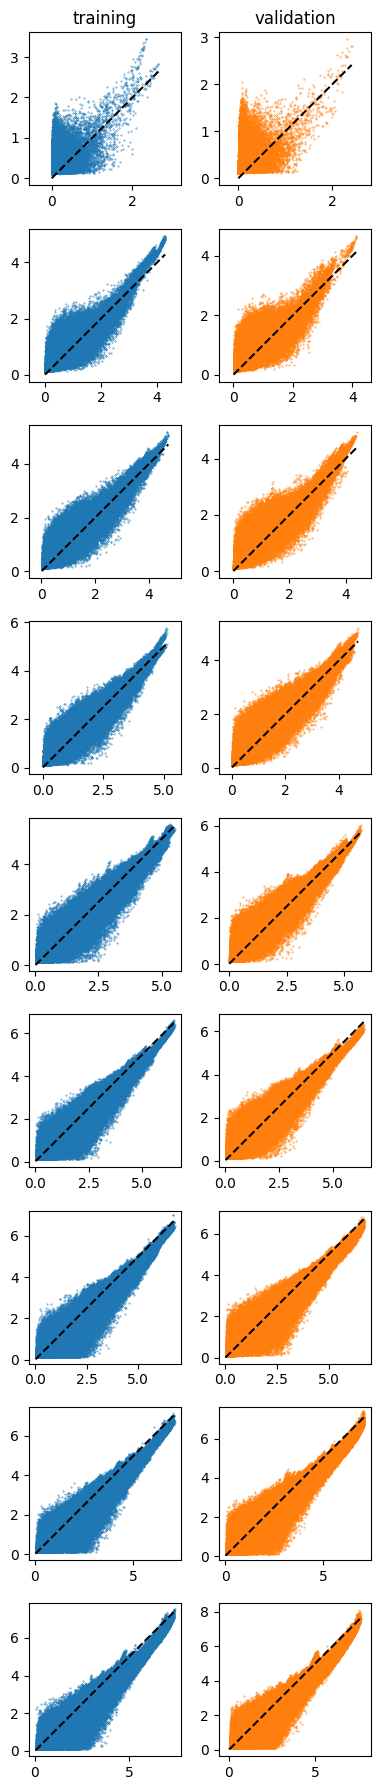

In [20]:
pred = model(X)
pred_vali = model(X_vali)

plot_preds(pred, Y, pred_vali, Y_vali)

1.183507


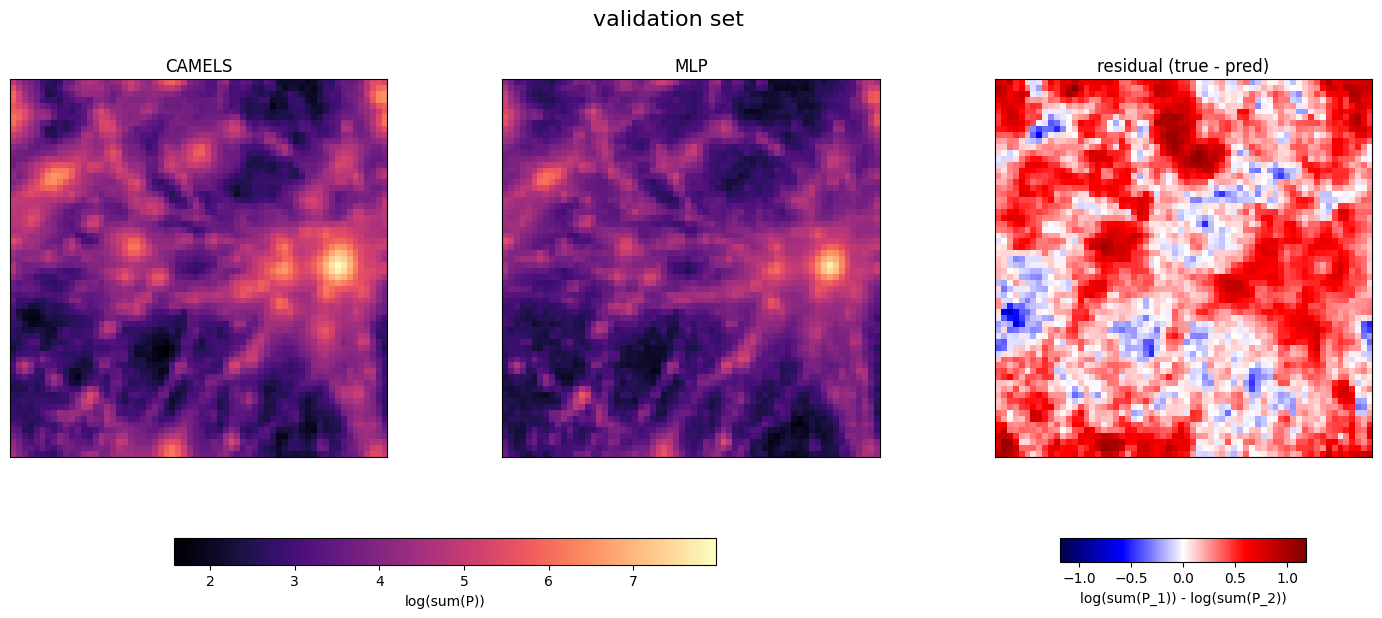

In [21]:
i = -1
P_mlp = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])

plot_comparison(P_camels, P_mlp, pred_label="MLP", suptitle="validation set")

## MLP + CNN

In [22]:
from jaxpm.nn import MLP, CNN, HybridNet

In [23]:
y_labels = ["P"]
# y_labels = ["U"]

X_particle, X_field, Y = get_data(train_dict, y_labels=y_labels)
X_particle_vali, X_field_vali, Y_vali = get_data(test_dict, y_labels=y_labels)

mlp = MLP(
    d_in=X_particle.shape[-1], 
    d_out=8, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

cnn = CNN(
    d_in=X_field.shape[-1], 
    d_out=8,
    d_hidden=16,
    n_hidden=1,
    kernel_size=(3, 3, 3),
    strides=1,
    rngs=nnx.Rngs(0)
)

model = HybridNet(
    mlp,
    cnn,
    d_out=Y.shape[-1],
    rngs=nnx.Rngs(0),
    batch_axis=False,
)

train=0.1194, vali=0.1882: 100%|██████████| 1000/1000 [00:21<00:00, 46.32it/s]


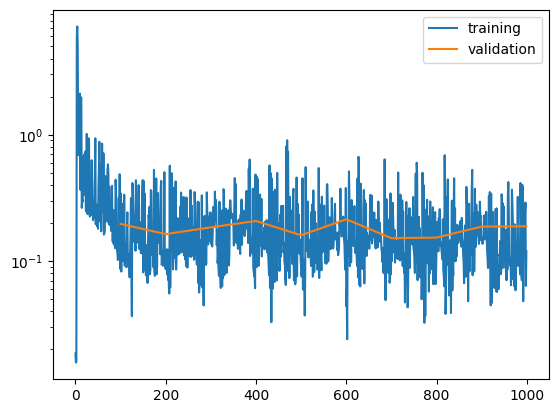

In [24]:
train_model(
    model,
    (train_dict["gas_poss"], X_particle, X_field),
    Y,
    (test_dict["gas_poss"], X_particle_vali, X_field_vali),
    Y_vali,
)

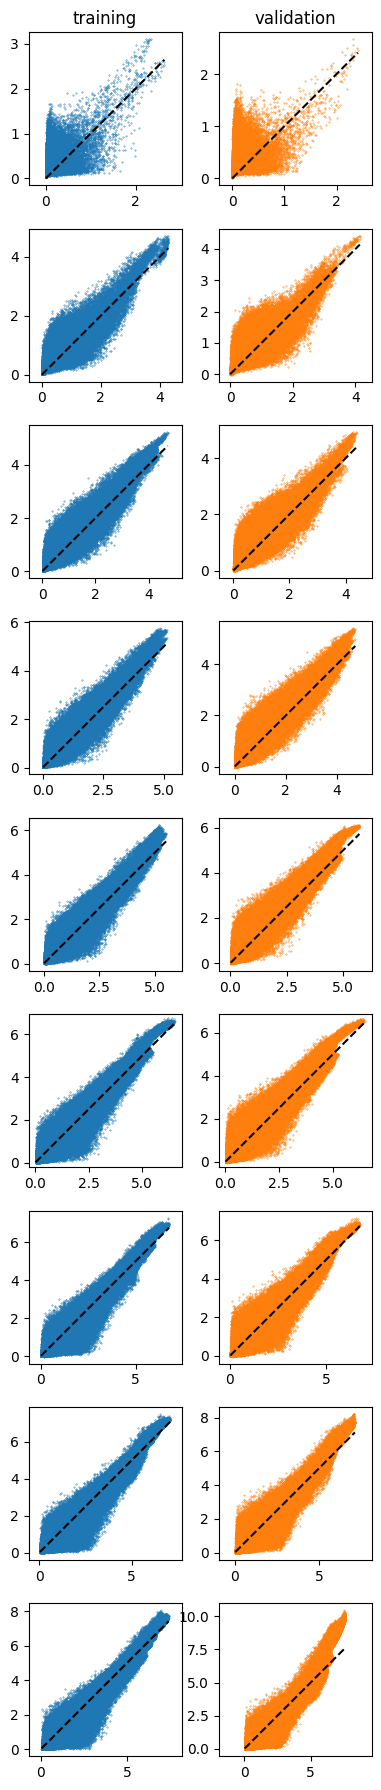

In [25]:
pred = jax.vmap(model, in_axes=0)(train_dict["gas_poss"], X_particle, X_field)
pred_vali = jax.vmap(model, in_axes=0)(test_dict["gas_poss"], X_particle_vali, X_field_vali)

plot_preds(pred, Y, pred_vali, Y_vali)

2.2517748


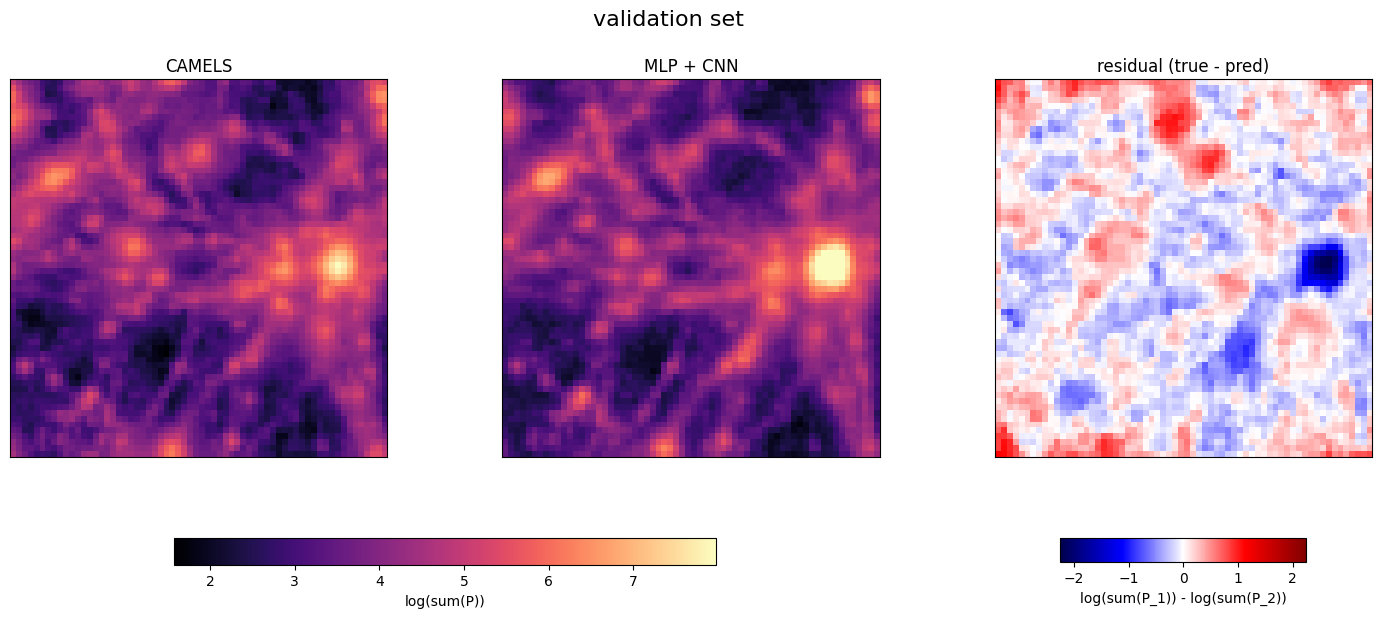

In [26]:
i = -1
P_hybrid = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])

plot_comparison(P_camels, P_hybrid, pred_label="MLP + CNN", suptitle="validation set")

## GNN

In [27]:
from jaxpm.nn import AttentionGNN
from jaxpm.graph import get_graph

In [28]:
from jaxpm.graph import get_edges

In [29]:
y_labels = ["P"]
# y_labels = ["U"]

particle_features, field_features = preprocess(train_dict)
# TODO add velocity features
X = get_graph(
    scales, 
    particle_features["gas_pos"], 
    particle_features["gas_rho"], 
    particle_features["gas_fscalar"], 
    k=16, 
    # boxsize=mesh_per_dim
)
_, _, Y = get_data(train_dict, y_labels=y_labels)

particle_features, field_features = preprocess(test_dict)
X_vali = get_graph(
    scales, 
    particle_features["gas_pos"], 
    particle_features["gas_rho"], 
    particle_features["gas_fscalar"], 
    k=16, 
    # boxsize=mesh_per_dim
)
_, _, Y_vali = get_data(test_dict, y_labels=y_labels)

In [30]:
model = AttentionGNN(
    d_node=X[0].nodes.shape[-1],
    d_edge=X[0].edges.shape[-1],
    d_query=16,
    n_hidden=4,
    d_out=Y.shape[-1],
    rngs=nnx.Rngs(0),
)

In [31]:
# model = AttentionGNN(
#     d_node=X.nodes.shape[-1],
#     d_edge=X.edges.shape[-1],
#     d_query=16,
#     n_hidden=4,
#     d_out=Y.shape[-1],
#     rngs=nnx.Rngs(0),
# )

train=0.0904, vali=0.1209: 100%|██████████| 1000/1000 [01:34<00:00, 10.64it/s]


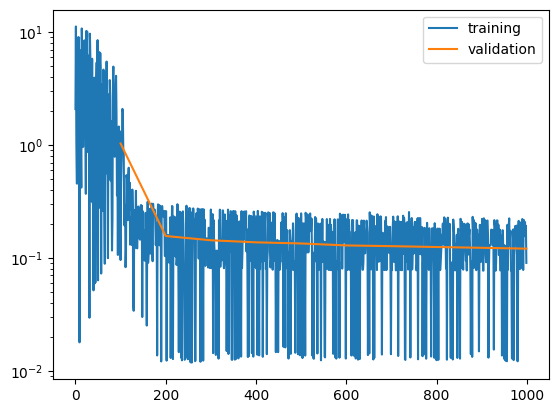

In [32]:
train_model(
    model,
    (X,),
    Y,
    (X_vali,),
    Y_vali,
)

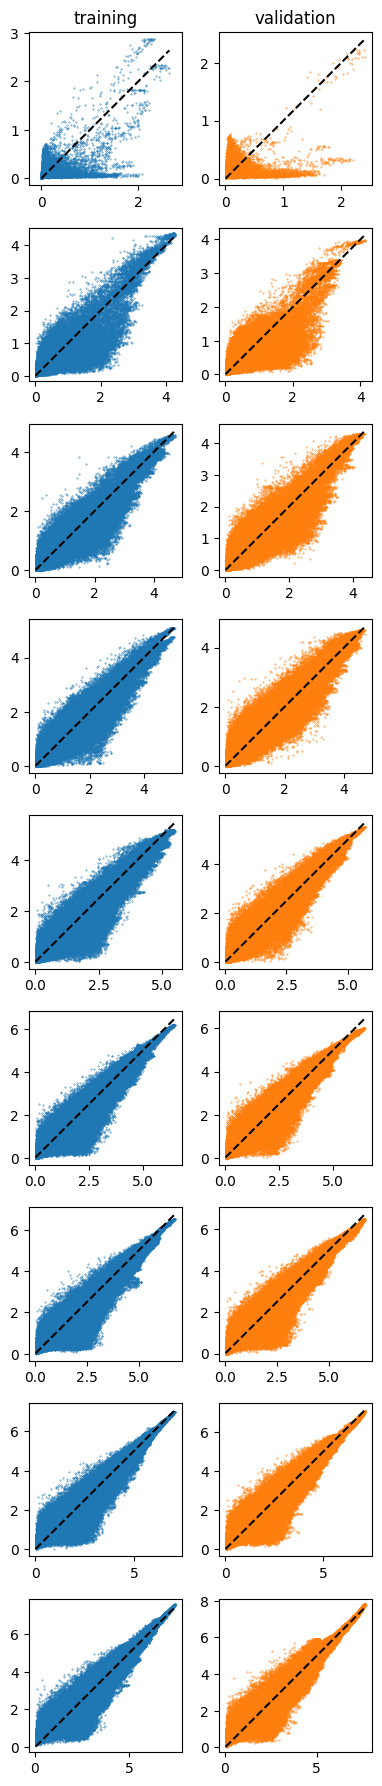

In [33]:
pred = []
for x in X:
    pred.append(model(x))
pred = jnp.stack(pred, axis=0)
    
pred_vali = []
for x in X_vali:
    pred_vali.append(model(x))
pred_vali = jnp.stack(pred_vali, axis=0)

plot_preds(pred, Y, pred_vali, Y_vali)

1.7553728


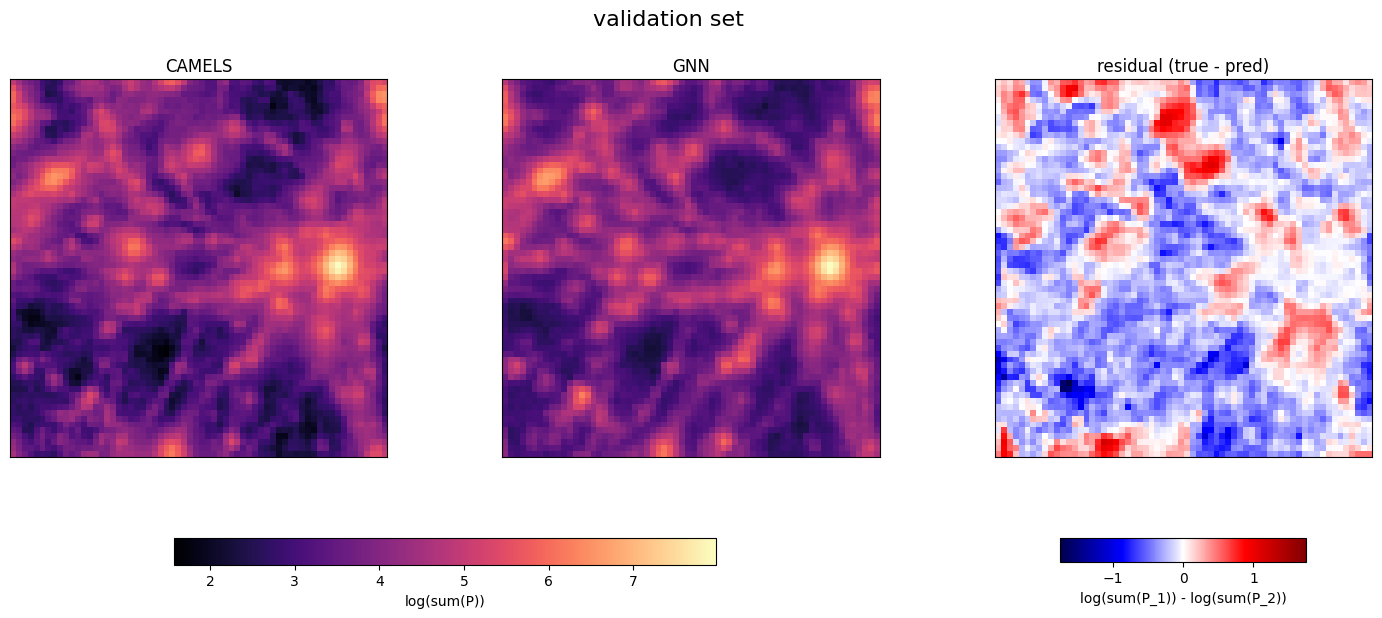

In [34]:
i = -1
P_gnn = normalized_paint(test_dict["gas_poss"][i], jnp.squeeze(10**pred_vali[i]) + 1)
P_camels = normalized_paint(test_dict["gas_poss"][i], test_dict["gas_Ps"][i])

plot_comparison(P_camels, P_gnn, pred_label="GNN", suptitle="validation set")

# field-level

## CNN

In [35]:
from jaxpm.nn import CNN